# Datathon Passos Mágicos - Análise Exploratória e Storytelling

Este notebook responde às 11 perguntas do desafio com base na base consolidada analítica e, quando necessário, na base reduzida para modelagem.

## Objetivos
- Entender a evolução dos indicadores pedagógicos, psicossociais e de engajamento;
- Identificar padrões de risco de defasagem;
- Avaliar a efetividade do programa ao longo dos anos e fases;
- Preparar insumos para o modelo preditivo e para o storytelling da apresentação final.

## Bases utilizadas
- Base analítica consolidada: `base_PEDE_consolidada_analitica.parquet`
- Base reduzida para ML: `base_processada_reduzida_ML.parquet`

In [2]:
# 2) Imports e configuraçãoimport warnings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

In [3]:
# 3) Carga das bases
df = pd.read_parquet("../data/processed/base_PEDE_consolidada_analitica.parquet")
df_ml = pd.read_parquet("../data/processed/base_processada_reduzida_ML.parquet")

print("Base analítica:", df.shape)
print("Base ML:", df_ml.shape)

display(df.head())
display(df_ml.head())


Base analítica: (3030, 55)
Base ML: (3030, 16)


,ano_pede,ra,fase,turma,nome,ano_nasc,data_nasc,idade,genero,ano_ingresso,instituicao_ensino,escola,ativo_inativo,pedra_2020,pedra_2021,pedra_2022,pedra_2023,pedra_2024,inde_2022,inde_2023,inde_2024,cg,cf,ct,n_av,avaliador_1,rec_av1,avaliador_2,rec_av2,avaliador_3,rec_av3,avaliador_4,rec_av4,avaliador_5,rec_av5,avaliador_6,rec_av6,iaa,ieg,ips,ipp,rec_psicologia,ida,mat,por,ing,indicado,atingiu_pv,ipv,ian,fase_ideal,defasagem,destaque_ieg,destaque_ida,destaque_ipv
0,2022,RA-1,7,A,Aluno-1,2003.0,NaT,19.0,Menina,2016,Escola Pública,<NA>,<NA>,Ametista,Ametista,Quartzo,<NA>,<NA>,5.783,NaN,NaN,753.0,18.0,10.0,4.0,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,None,None,None,None,8.3,4.1,5.6,NaN,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,2022,RA-2,7,A,Aluno-2,2005.0,NaT,17.0,Menina,2017,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ametista,<NA>,<NA>,7.055,NaN,NaN,469.0,8.0,3.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,8.8,5.2,6.3,NaN,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,2022,RA-3,7,A,Aluno-3,2005.0,NaT,17.0,Menina,2016,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ágata,<NA>,<NA>,6.591,NaN,NaN,629.0,13.0,6.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,0.0,7.9,5.6,NaN,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,2022,RA-4,7,A,Aluno-4,2005.0,NaT,17.0,Menino,2017,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Quartzo,<NA>,<NA>,5.951,NaN,NaN,731.0,15.0,7.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,None,None,None,None,8.8,4.5,5.6,NaN,Requer avaliação,5.0,2.8,3.5,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,2022,RA-5,7,A,Aluno-5,2005.0,NaT,17.0,Menina,2016,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ametista,<NA>,<NA>,7.427,NaN,NaN,344.0,6.0,2.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,7.9,8.6,5.6,NaN,Requer avaliação,5.2,7.0,2.9,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


,ano_pede,inde,n_av,iaa,ieg,ips,ipp,ida,mat,por,ing,ipv,ian,fase_ideal,defasagem,risco_defasagem_atual
0,2022,5.783,4.0,8.3,4.1,5.6,NaN,4.0,2.7,3.5,6.0,7.278,5.0,Fase 8 (Universitários),-1,0
1,2022,7.055,4.0,8.8,5.2,6.3,NaN,6.8,6.3,4.5,9.7,6.778,10.0,Fase 7 (3º EM),0,0
2,2022,6.591,4.0,0.0,7.9,5.6,NaN,5.6,5.8,4.0,6.9,7.556,10.0,Fase 7 (3º EM),0,0
3,2022,5.951,4.0,8.8,4.5,5.6,NaN,5.0,2.8,3.5,8.7,5.278,10.0,Fase 7 (3º EM),0,0
4,2022,7.427,4.0,7.9,8.6,5.6,NaN,5.2,7.0,2.9,5.7,7.389,10.0,Fase 7 (3º EM),0,0


In [4]:
# 4) Padronizações auxiliares
# cria coluna inde única na base analítica
df["inde"] = np.nan

if "inde_2022" in df.columns:
    df.loc[df["ano_pede"] == 2022, "inde"] = df["inde_2022"]
if "inde_2023" in df.columns:
    df.loc[df["ano_pede"] == 2023, "inde"] = df["inde_2023"]
if "inde_2024" in df.columns:
    df.loc[df["ano_pede"] == 2024, "inde"] = df["inde_2024"]

# garantir numéricos
cols_numericas = [
    "idade", "ano_ingresso", "inde", "iaa", "ieg", "ips", "ipp",
    "ida", "mat", "por", "ing", "ipv", "ian", "defasagem"
]

for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# categorias úteis
for col in ["fase", "turma", "genero", "instituicao_ensino", "pedra_2022", "pedra_2023", "pedra_2024"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ano_pede            3030 non-null   int64         
 1   ra                  3030 non-null   string        
 2   fase                3030 non-null   string        
 3   turma               3030 non-null   string        
 4   nome                3030 non-null   string        
 5   ano_nasc            860 non-null    float64       
 6   data_nasc           2170 non-null   datetime64[ns]
 7   idade               2631 non-null   float64       
 8   genero              3030 non-null   string        
 9   ano_ingresso        3030 non-null   int64         
 10  instituicao_ensino  3029 non-null   string        
 11  escola              1155 non-null   string        
 12  ativo_inativo       0 non-null      string        
 13  pedra_2020          754 non-null    string      

In [5]:
# 5) Funções auxiliares
def plot_bar(data, x, y, title, figsize=(10,5), rotation=0):
    plt.figure(figsize=figsize)
    sns.barplot(data=data, x=x, y=y)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_line(data, x, y, hue=None, title="", figsize=(10,5), rotation=0, marker="o"):
    plt.figure(figsize=figsize)
    sns.lineplot(data=data, x=x, y=y, hue=hue, marker=marker)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_heatmap_corr(df_corr, title="Mapa de Correlação"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def categorizar_defasagem(valor):
    if pd.isna(valor):
        return "Sem informação"
    if valor <= 0:
        return "Sem defasagem"
    elif valor == 1:
        return "Defasagem leve"
    elif valor == 2:
        return "Defasagem moderada"
    else:
        return "Defasagem severa"

df["categoria_defasagem"] = df["defasagem"].apply(categorizar_defasagem)

### 9. Previsão de risco com Machine Learning

In [ ]:
# 37) Construção do target de risco
# alvo principal: risco de defasagem futura, se for possível usar histórico por RA
base_modelo = df.copy()

if "ra" in base_modelo.columns:
    base_modelo = base_modelo.sort_values(["ra", "ano_pede"]).copy()

    # risco atual
    base_modelo["risco_atual"] = (base_modelo["defasagem"].fillna(0) > 0).astype(int)

    # risco futuro = o aluno apresentar defasagem no próximo ano
    base_modelo["risco_futuro"] = base_modelo.groupby("ra")["risco_atual"].shift(-1)

    # mantemos só registros com alvo conhecido
    base_modelo = base_modelo[base_modelo["risco_futuro"].notna()].copy()
    base_modelo["risco_futuro"] = base_modelo["risco_futuro"].astype(int)

    alvo = "risco_futuro"
else:
    # fallback
    base_modelo["risco_futuro"] = (base_modelo["defasagem"].fillna(0) > 0).astype(int)
    alvo = "risco_futuro"

print("Shape base_modelo:", base_modelo.shape)
print("Distribuição do alvo:")
display(base_modelo[alvo].value_counts(normalize=True))

Shape base_modelo: (1369, 59)
Distribuição do alvo:


risco_futuro
0    0.902118
1    0.097882
Name: proportion, dtype: float64

### Interpretação dos resultados - 37) Construção do target de risco



In [7]:
# 38) Seleção de variáveis
features = [
    "ano_pede", "idade", "fase", "turma", "genero",
    "iaa", "ieg", "ips", "ipp", "ida", "mat", "por", "ing",
    "ipv", "ian", "inde"
]

features = [c for c in features if c in base_modelo.columns]

X = base_modelo[features].copy()
y = base_modelo[alvo].copy()

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['ano_pede', 'idade', 'iaa', 'ieg', 'ips', 'ipp', 'ida', 'mat', 'por', 'ing', 'ipv', 'ian', 'inde']
Categóricas: ['fase', 'turma', 'genero']


### Interpretação dos resultados - 38) Seleção de variáveis


In [8]:
# 39) Pipeline e treino
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)
pred_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))

try:
    auc = roc_auc_score(y_test, pred_prob)
    print("ROC AUC:", round(auc, 4))
except Exception as e:
    print("Não foi possível calcular ROC AUC:", e)

              precision    recall  f1-score   support

           0       0.95      0.85      0.90       309
           1       0.31      0.62      0.42        34

    accuracy                           0.83       343
   macro avg       0.63      0.73      0.66       343
weighted avg       0.89      0.83      0.85       343

ROC AUC: 0.8434


### 39) Pipeline e treino - A ser gerada

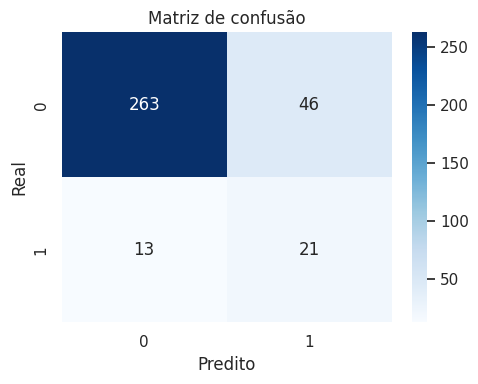

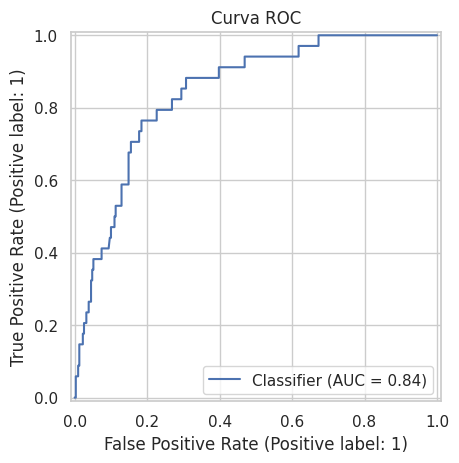

In [9]:
# 40) Matriz de confusão e curva ROC
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, pred_prob)
plt.title("Curva ROC")
plt.show()

### 40) Analise a ser gerada

,feature,importance
11,num__ian,0.201728
10,num__ipv,0.113409
12,num__inde,0.097620
5,num__ipp,0.076844
4,num__ips,0.068629
3,num__ieg,0.058758
1,num__idade,0.047578
6,num__ida,0.042366
21,cat__fase_ALFA,0.042221
25,cat__fase_FASE 4,0.024708


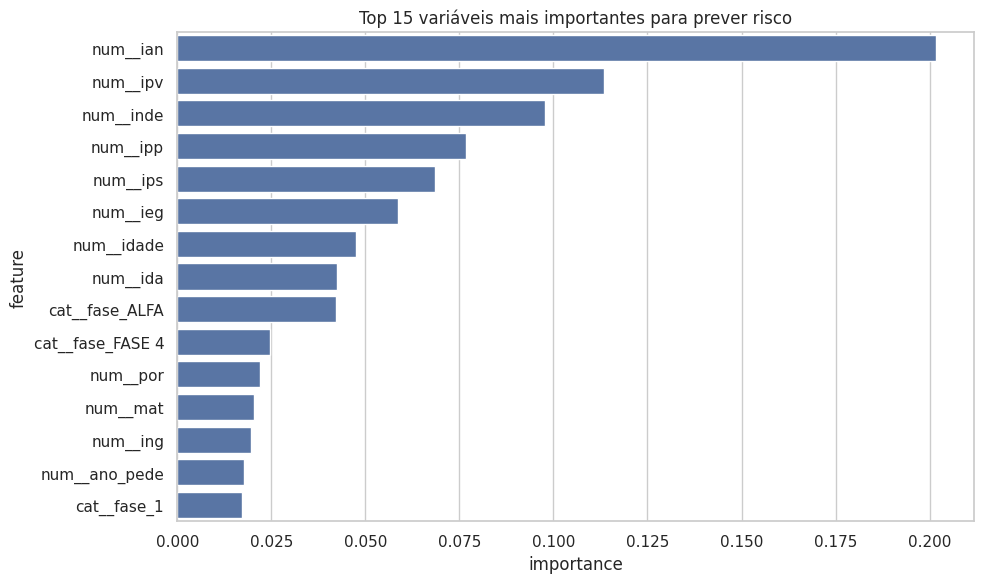

In [10]:
# 41) Importância das variáveis
# tenta recuperar nomes das colunas após preprocessamento
feature_names = pipeline.named_steps["prep"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

display(imp_df.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x="importance", y="feature")
plt.title("Top 15 variáveis mais importantes para prever risco")
plt.tight_layout()
plt.show()

### 41) Importância das variáveis - gerar análise

In [11]:
# 42) Exemplos de probabilidade de risco
resultado_risco = X_test.copy()
resultado_risco["risco_real"] = y_test.values
resultado_risco["probabilidade_risco"] = pred_prob
resultado_risco["risco_predito"] = pred

display(
    resultado_risco
    .sort_values("probabilidade_risco", ascending=False)
    .head(20)
)

,ano_pede,idade,fase,turma,genero,iaa,ieg,ips,ipp,ida,mat,por,ing,ipv,ian,inde,risco_real,probabilidade_risco,risco_predito
1497,2023,13.0,FASE 3,3D,Feminino,7.5,9.9,2.52,7.968750,6.9,NaN,NaN,NaN,8.255000,10.0,7.809875,0,0.842457,1
1558,2023,NaN,FASE 3,3L,Feminino,8.8,10.0,2.52,8.125000,8.1,NaN,NaN,NaN,8.045000,10.0,8.168600,1,0.835572,1
1276,2023,10.0,FASE 2,2A,Masculino,9.5,9.7,2.52,8.541667,7.5,NaN,NaN,NaN,9.007500,10.0,8.297867,1,0.834762,1
1562,2023,13.0,FASE 3,3L,Masculino,9.2,9.9,2.52,7.812500,7.5,NaN,NaN,NaN,8.377500,10.0,8.105550,0,0.830093,1
1575,2023,NaN,FASE 3,3N,Masculino,8.3,9.5,2.52,7.812500,7.2,NaN,NaN,NaN,8.042500,10.0,7.821817,0,0.816936,1
1743,2023,13.0,FASE 5,5M,Feminino,7.1,9.9,2.52,8.593750,6.8,NaN,NaN,NaN,8.630000,10.0,7.879008,1,0.815256,1
1572,2023,NaN,FASE 3,3M,Feminino,8.8,9.9,2.52,7.812500,6.4,NaN,NaN,NaN,7.792500,10.0,7.726850,0,0.815098,1
1341,2023,10.0,FASE 2,2G,Feminino,10.0,9.9,2.52,8.958333,8.7,NaN,NaN,NaN,8.953333,10.0,8.658700,1,0.812965,1
1275,2023,11.0,FASE 2,2A,Masculino,9.0,10.0,2.52,9.791667,9.7,NaN,NaN,NaN,9.762500,10.0,9.013867,1,0.812298,1
1292,2023,11.0,FASE 2,2B,Masculino,9.5,10.0,2.52,8.750000,7.7,NaN,NaN,NaN,8.590000,10.0,8.325200,0,0.807716,1


### Leitura analítica
- O modelo estima a probabilidade de o aluno entrar em risco de defasagem no período seguinte.
- As variáveis mais importantes ajudam a identificar quais padrões antecipam vulnerabilidade.
- Esse resultado servirá de base para o notebook específico de modelagem e para o app em Streamlit.